In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import jarque_bera, skew, kurtosis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

## 1. LOAD AND CLEAN DATA

In [2]:
df = pd.read_csv("Desktop/BTCUSD_5min_2016_2025.csv")

In [3]:
df.head()

,timestamp,open,high,low,close,volume
0,2016-01-01 00:00:00,430.89,431.06,430.19,431.06,1.256050
1,2016-01-01 00:05:00,431.06,432.53,430.21,432.51,10.871870
2,2016-01-01 00:10:00,432.38,432.38,431.46,431.46,0.425723
3,2016-01-01 00:15:00,432.38,432.58,431.47,431.47,2.894182
4,2016-01-01 00:20:00,431.58,432.40,431.46,431.46,4.756002


In [4]:
# Parse datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

In [5]:
# Check the number of missing values in 'timestamp' and 'close' columns
print(df[["timestamp", "close"]].isna().sum())

timestamp    0
close        0
dtype: int64


In [6]:
# Check how many 'close' values are zero or negative
print("Zero or negative close prices:", (df["close"] <= 0).sum())

Zero or negative close prices: 0


In [7]:
# Check whether the 'timestamp' column is sorted in increasing order
print("timestamp sorted:", df["timestamp"].is_monotonic_increasing)

timestamp sorted: True


In [8]:
# Set datetime index
df = df.set_index("timestamp")
df.index.name = "datetime_utc"

In [9]:
# Count duplicate timestamps
duplicate_count = df.index.duplicated().sum()
print("Number of duplicate timestamps:", duplicate_count)

Number of duplicate timestamps: 0


In [10]:
print("Shape:", df.shape)
print("Time range:", df.index.min(), "to", df.index.max())

Shape: (1052064, 5)
Time range: 2016-01-01 00:00:00+00:00 to 2025-12-31 23:55:00+00:00


In [11]:
df.dtypes

open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object

In [12]:
df.head()

,open,high,low,close,volume
datetime_utc,,,,,
2016-01-01 00:00:00+00:00,430.89,431.06,430.19,431.06,1.256050
2016-01-01 00:05:00+00:00,431.06,432.53,430.21,432.51,10.871870
2016-01-01 00:10:00+00:00,432.38,432.38,431.46,431.46,0.425723
2016-01-01 00:15:00+00:00,432.38,432.58,431.47,431.47,2.894182
2016-01-01 00:20:00+00:00,431.58,432.40,431.46,431.46,4.756002


## 2. COMPUTE 5-MIN LOG RETURNS AND HOURLY REALIZED VOLATILITY

In [13]:
# Method: Andersen et al. (2003) — sum of squared intraday 5-min log returns
# K = 12 five-minute intervals per hour (60 / 5 = 12)
# Log returns computed WITHIN each hour to avoid between-hour contamination.

K_EXPECTED    = 12    # theoretical 5-min intervals per hour
MIN_OBS_RATIO = 0.80  # require at least 80% coverage (≥ 10 valid returns) per hour

In [14]:
# Assign trading hour (UTC date + hour of each 5-min bar)
df["hour"] = df.index.floor("h")

In [15]:
# Log price
df["log_close"] = np.log(df["close"])

In [16]:
# groupby hour before diff() — prevents between-hour gaps contaminating returns
df["r_5m"] = df.groupby("hour")["log_close"].diff()  # NaN at first bar of each hour

In [17]:
# Squared intraday returns (RV building block)
df["r2_5m"] = df["r_5m"] ** 2

In [18]:
# Aggregate to hourly: sum squared returns + count valid observations
rv_hourly = (
    df.groupby("hour")
    .agg(
        RV    = ("r2_5m", "sum"),
        n_obs = ("r2_5m", "count")
    )
)

In [19]:
# Quality filter: flag hours with fewer than 80% of expected bars (< 10 obs)
rv_hourly["sufficient_data"] = rv_hourly["n_obs"] >= int(MIN_OBS_RATIO * K_EXPECTED)

In [20]:
# Set RV to NaN for low-coverage hours
rv_hourly.loc[~rv_hourly["sufficient_data"], "RV"] = np.nan

In [21]:
# Realized Volatility (hourly scale: square root of RV)
rv_hourly["RVol"] = np.sqrt(rv_hourly["RV"])

In [22]:
# Log-transform RV — standard in forecasting literature (stabilises variance, reduces skewness, see Andersen et al. 2003; Dudek et al. 2024)
rv_hourly["log_RV"] = np.log(rv_hourly["RV"].replace(0, np.nan))

In [23]:
# Convert date index to DatetimeIndex for plotting
rv_hourly.index = pd.to_datetime(rv_hourly.index, utc=True)

In [24]:
rv_hourly.head()

,RV,n_obs,sufficient_data,RVol,log_RV
hour,,,,,
2016-01-01 00:00:00+00:00,0.000031,11,True,0.005578,-10.377671
2016-01-01 01:00:00+00:00,0.000063,11,True,0.007949,-9.669415
2016-01-01 02:00:00+00:00,0.000050,11,True,0.007104,-9.894240
2016-01-01 03:00:00+00:00,0.000049,11,True,0.006976,-9.930451
2016-01-01 04:00:00+00:00,0.000062,11,True,0.007887,-9.685073


In [25]:
rv_hourly.tail()

,RV,n_obs,sufficient_data,RVol,log_RV
hour,,,,,
2025-12-31 19:00:00+00:00,2.767427e-06,11,True,0.001664,-12.797592
2025-12-31 20:00:00+00:00,9.230502e-06,11,True,0.003038,-11.592997
2025-12-31 21:00:00+00:00,8.194372e-07,11,True,0.000905,-14.014648
2025-12-31 22:00:00+00:00,3.833078e-06,11,True,0.001958,-12.471842
2025-12-31 23:00:00+00:00,7.211346e-07,11,True,0.000849,-14.142440


In [26]:
print("Hours         :", len(rv_hourly))
print("Missing RV    :", rv_hourly["RV"].isna().sum())
print("Low-obs hours :", (~rv_hourly["sufficient_data"]).sum())
print(f"Avg obs/hour  : {rv_hourly['n_obs'].mean():.1f}  "
      f"(expected {K_EXPECTED-1} valid returns, {K_EXPECTED} intervals)")

Hours         : 87672
Missing RV    : 0
Low-obs hours : 0
Avg obs/hour  : 11.0  (expected 11 valid returns, 12 intervals)


In [27]:
print("Note: In this dataset, all days pass the 80% coverage filter (Low-obs days = 0).")

Note: In this dataset, all days pass the 80% coverage filter (Low-obs days = 0).


## 3. DESCRIPTIVE ANALYSIS — PLOTS + SUMMARY STATS + NORMALITY

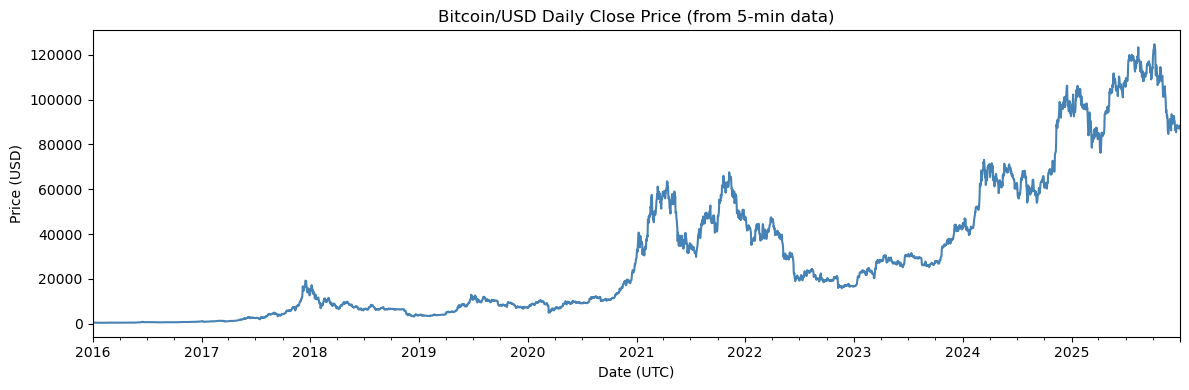

In [28]:
# 3.1  Daily close price
plt.figure(figsize=(12, 4))
df["close"].resample("1D").last().plot(color="steelblue")
plt.title("Bitcoin/USD Daily Close Price (from 5-min data)")
plt.xlabel("Date (UTC)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

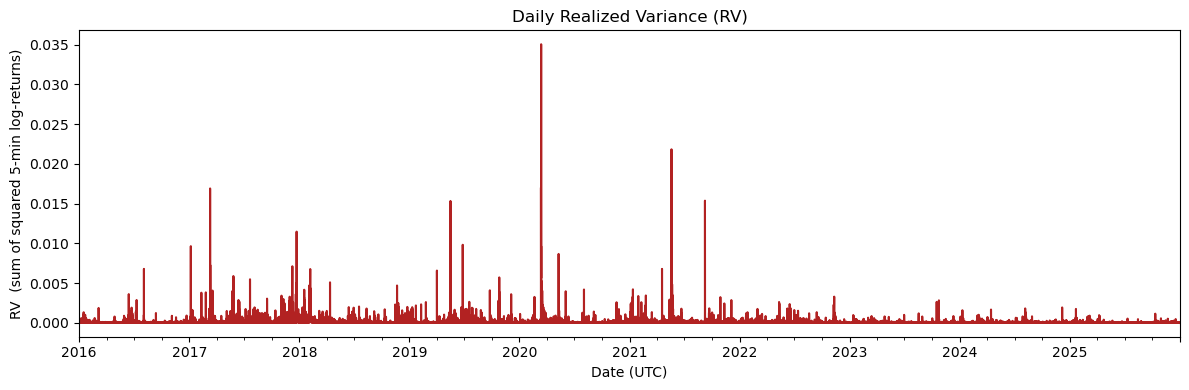

In [29]:
# 3.2  Daily Realized Variance (RV) 
plt.figure(figsize=(12, 4))
rv_hourly["RV"].plot(color="firebrick")
plt.title("Daily Realized Variance (RV)")
plt.xlabel("Date (UTC)")
plt.ylabel("RV  (sum of squared 5-min log-returns)")
plt.tight_layout()
plt.show()

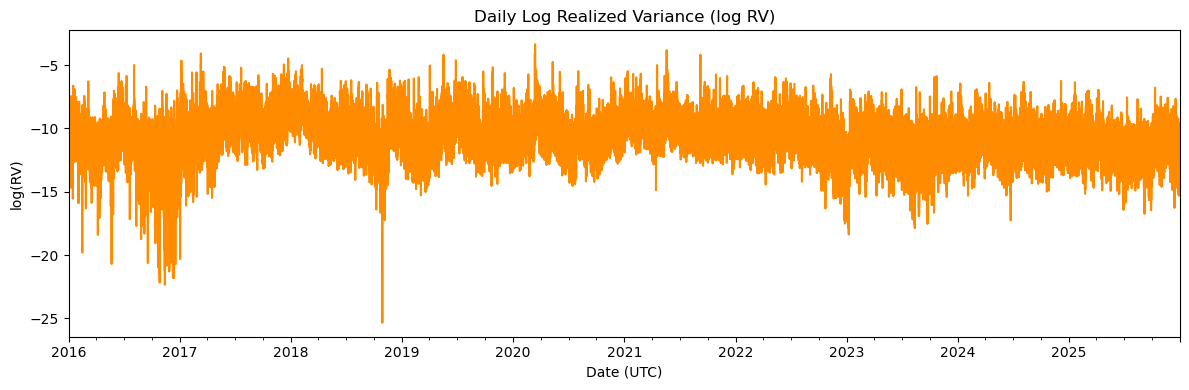

In [30]:
# 3.3  Log RV
plt.figure(figsize=(12, 4))
rv_hourly["log_RV"].plot(color="darkorange")
plt.title("Daily Log Realized Variance (log RV)")
plt.xlabel("Date (UTC)")
plt.ylabel("log(RV)")
plt.tight_layout()
plt.show()

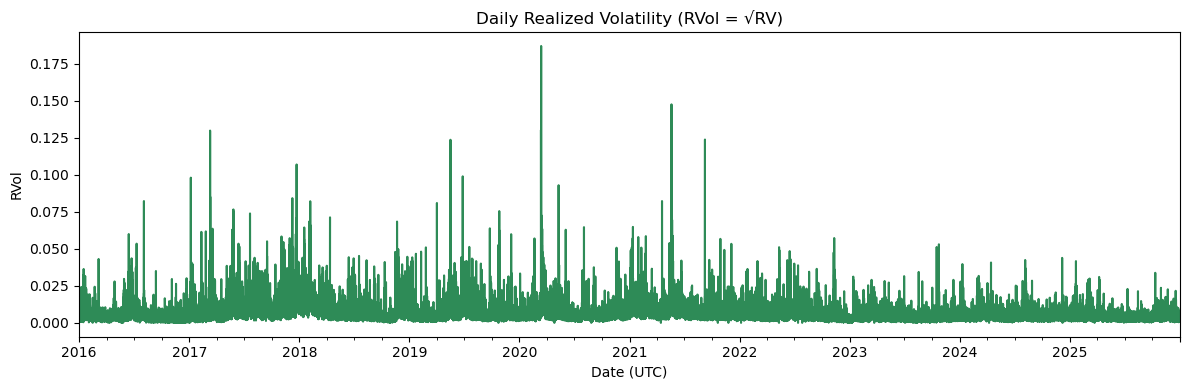

In [31]:
# 3.4  Realized Volatility (RVol = sqrt(RV)) 
plt.figure(figsize=(12, 4))
rv_hourly["RVol"].plot(color="seagreen")
plt.title("Daily Realized Volatility (RVol = √RV)")
plt.xlabel("Date (UTC)")
plt.ylabel("RVol")
plt.tight_layout()
plt.show()

In [32]:
# 3.5  Summary statistics
returns   = df["r_5m"].dropna()
rv_series = rv_hourly["RV"].dropna()
logrv     = rv_hourly["log_RV"].dropna()

pctiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

ret_stats   = returns.describe(percentiles=pctiles)
rv_stats    = rv_series.describe(percentiles=pctiles)
logrv_stats = logrv.describe(percentiles=pctiles)

print("\n" + "="*55)
print("5-min Log Returns — Summary Statistics")
print("="*55)
print(ret_stats)

print("\n" + "="*55)
print("Hourly Realized Variance (RV) — Summary Statistics")
print("="*55)
print(rv_stats)

print("\n" + "="*55)
print("Hourly Log Realized Variance (log RV) — Summary Statistics")
print("="*55)
print(logrv_stats)

# Extended stats table
def extended_stats(series, name):
    s = series.dropna()
    return pd.Series({
        "N"           : len(s),
        "Mean"        : s.mean(),
        "Median"      : s.median(),
        "Std Dev"     : s.std(),
        "Min"         : s.min(),
        "Max"         : s.max(),
        "Skewness"    : skew(s),
        "Kurtosis(ex)": kurtosis(s),
        "1%"          : s.quantile(0.01),
        "5%"          : s.quantile(0.05),
        "95%"         : s.quantile(0.95),
        "99%"         : s.quantile(0.99),
    }, name=name)

stats_table = pd.concat([
    extended_stats(returns,   "5-min Returns"),
    extended_stats(rv_series, "Hourly RV"),
    extended_stats(logrv,     "Hourly log RV"),
], axis=1)

print("\n" + "="*55)
print("Extended Descriptive Statistics")
print("="*55)
print(stats_table.to_string())


5-min Log Returns — Summary Statistics
count    964392.000000
mean          0.000005
std           0.002335
min          -0.102982
1%           -0.006665
5%           -0.003021
25%          -0.000774
50%           0.000000
75%           0.000804
95%           0.003029
99%           0.006464
max           0.081764
Name: r_5m, dtype: float64

Hourly Realized Variance (RV) — Summary Statistics
count    8.767200e+04
mean     5.996548e-05
std      2.666528e-04
min      0.000000e+00
1%       5.529062e-07
5%       1.867463e-06
25%      7.502500e-06
50%      1.832138e-05
75%      4.707405e-05
95%      2.126882e-04
99%      6.610831e-04
max      3.503037e-02
Name: RV, dtype: float64

Hourly Log Realized Variance (log RV) — Summary Statistics
count    87650.000000
mean       -10.879699
std          1.460909
min        -25.354128
1%         -14.384196
5%         -13.188065
25%        -11.799382
50%        -10.906993
75%         -9.963451
95%         -8.455507
99%         -7.321438
max         -3

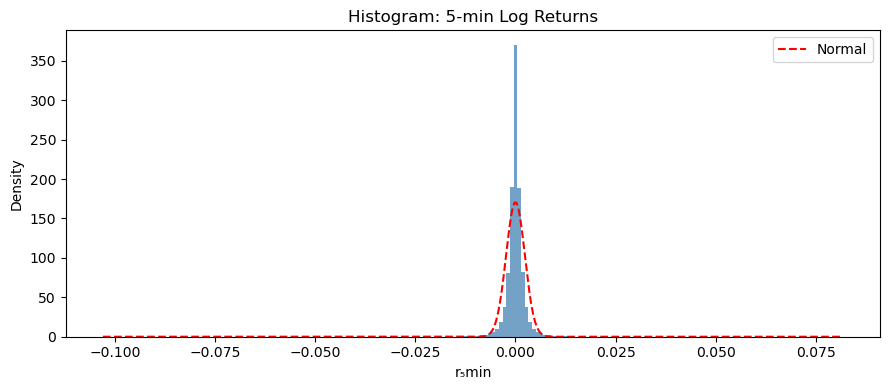

In [33]:
# 3.6  Histogram: 5-min returns 
plt.figure(figsize=(9, 4))
plt.hist(returns, bins=200, density=True, color="steelblue", alpha=0.75)
plt.title("Histogram: 5-min Log Returns")
plt.xlabel("r₅min")
plt.ylabel("Density")

# Add normal reference curve
from scipy.stats import norm as _norm
x = np.linspace(returns.min(), returns.max(), 400)
plt.plot(x, _norm.pdf(x, returns.mean(), returns.std()),
         "r--", lw=1.5, label="Normal")
plt.legend()
plt.tight_layout()
plt.show()

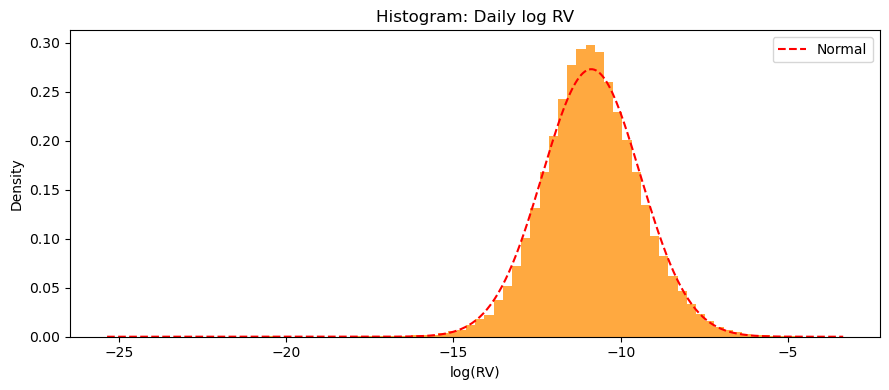

In [34]:
# 3.7  Histogram: log RV 
plt.figure(figsize=(9, 4))
plt.hist(logrv, bins=80, density=True, color="darkorange", alpha=0.75)
plt.title("Histogram: Daily log RV")
plt.xlabel("log(RV)")
plt.ylabel("Density")
x2 = np.linspace(logrv.min(), logrv.max(), 400)
plt.plot(x2, _norm.pdf(x2, logrv.mean(), logrv.std()),
         "r--", lw=1.5, label="Normal")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# 3.8  Normality tests (Jarque-Bera) 
jb_r_stat,  jb_r_p  = jarque_bera(returns)
jb_l_stat,  jb_l_p  = jarque_bera(logrv)

print("\n" + "="*55)
print("Normality Test — Jarque-Bera")
print("="*55)
print(f"{'Series':<22} {'JB Statistic':>15} {'p-value':>12}")
print("-"*50)
print(f"{'5-min Returns':<22} {jb_r_stat:>15.4f} {jb_r_p:>12.4g}")
print(f"{'Daily log RV':<22} {jb_l_stat:>15.4f} {jb_l_p:>12.4g}")

print("\nSkewness / Excess Kurtosis:")
print(f"  Returns  — Skew: {skew(returns):.4f}   Kurt: {kurtosis(returns):.4f}")
print(f"  log RV   — Skew: {skew(logrv):.4f}   Kurt: {kurtosis(logrv):.4f}")


Normality Test — Jarque-Bera
Series                    JB Statistic      p-value
--------------------------------------------------
5-min Returns           179288246.0695            0
Daily log RV                 8827.5038            0

Skewness / Excess Kurtosis:
  Returns  — Skew: -0.3351   Kurt: 66.7933
  log RV   — Skew: -0.1098   Kurt: 1.5391


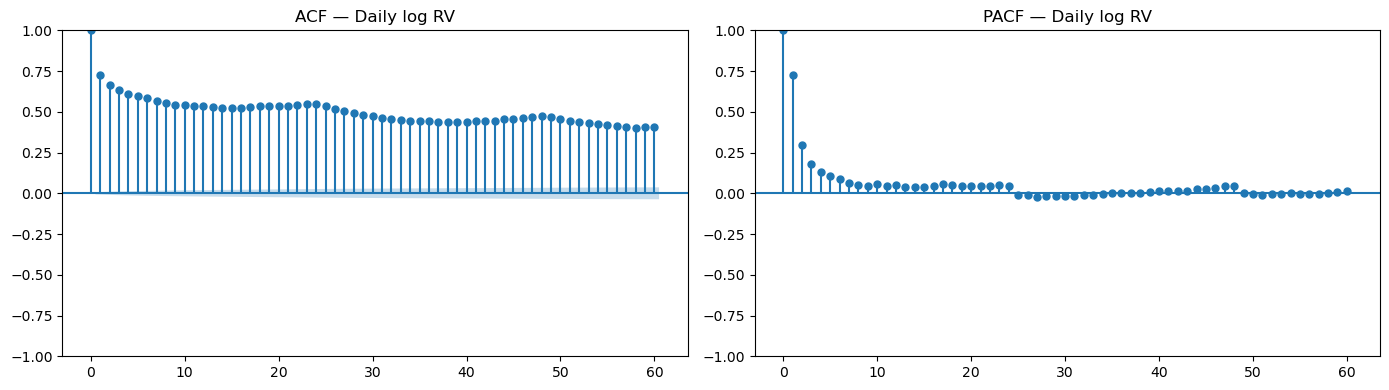

In [36]:
# 3.9  ACF / PACF of log RV 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(logrv, lags=60, alpha=0.05, ax=axes[0])
axes[0].set_title("ACF — Daily log RV")

plot_pacf(logrv, lags=60, method="ywm", alpha=0.05, ax=axes[1])
axes[1].set_title("PACF — Daily log RV")

plt.tight_layout()
plt.show()

In [37]:
# 3.10  Autocorrelation at HAR lags 
# HAR-I model uses hourly (1), daily (24), weekly (168) lags
har_lags = [1, 12, 24, 48, 168, 336, 720]
labels   = ["1h", "12h", "1d", "2d", "1w", "2w", "1m"]
acf_vals = {lag: logrv.autocorr(lag=lag) for lag in har_lags}

print("\n" + "="*55)
print("Autocorrelations of log RV at HAR-relevant lags")
print("="*55)
print(f"{'Lag (days)':<15} {'Label':<12} {'Autocorr':>10}")
print("-"*38)
labels = ["1d","1w","2w","1m","3m","6m","1y"]
for lag, lab in zip(har_lags, labels):
    print(f"{lag:<15} {lab:<12} {acf_vals[lag]:>10.4f}")


Autocorrelations of log RV at HAR-relevant lags
Lag (days)      Label          Autocorr
--------------------------------------
1               1d               0.7254
12              1w               0.5345
24              2w               0.5511
48              1m               0.4770
168             3m               0.4686
336             6m               0.4124
720             1y               0.2879


In [38]:
# 3.11  ADF stationarity test on log RV 
from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(logrv.dropna(), autolag="AIC")

print("\n" + "=" * 55)
print("ADF Stationarity Test — log RV")
print("=" * 55)
print(f"ADF Statistic : {adf_res[0]:.6f}")
print(f"p-value       : {adf_res[1]:.6g}")
print(f"Used lag      : {adf_res[2]}")
print(f"N obs         : {adf_res[3]}")
print("Critical values:")
for k, v in adf_res[4].items():
    print(f"  {k} : {v:.6f}")


ADF Stationarity Test — log RV
ADF Statistic : -13.867788
p-value       : 6.54892e-26
Used lag      : 66
N obs         : 87583
Critical values:
  1% : -3.430425
  5% : -2.861573
  10% : -2.566788


## 4. VOLATILITY CLUSTERING AND ARCH EFFECTS

In [39]:
# Hourly return = sum of 5-min returns within each hour
hourly_ret = df.groupby("hour")["r_5m"].sum()
hourly_ret.index = pd.to_datetime(hourly_ret.index, utc=True)
hourly_ret = hourly_ret.dropna()

In [40]:
# Squared hourly returns (clustering visual proxy)
hourly_r2 = hourly_ret ** 2

<Figure size 1000x300 with 0 Axes>

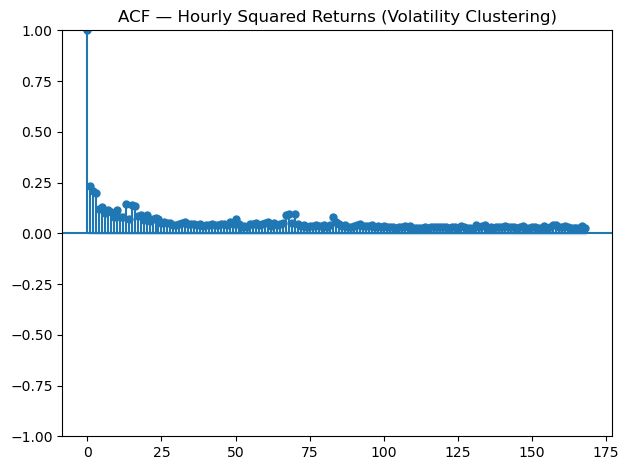

In [41]:
# 4.1  ACF of squared hourly returns
plt.figure(figsize=(10, 3))
plot_acf(hourly_r2, lags=168, alpha=0.05)
plt.title("ACF — Hourly Squared Returns (Volatility Clustering)")
plt.tight_layout()
plt.show()

In [42]:
# 4.2  Ljung-Box test on squared hourly returns
lb_r2 = acorr_ljungbox(hourly_r2, lags=[24, 48, 168, 336], return_df=True)
print("\n" + "="*55)
print("Ljung-Box Test — Hourly Squared Returns (Clustering)")
print("="*55)
print(lb_r2.to_string())
print("\nAll p-values << 0.05 => significant serial correlation in squared")
print("returns confirms volatility clustering (ARCH effect present).")


Ljung-Box Test — Hourly Squared Returns (Clustering)
          lb_stat  lb_pvalue
24   30456.005011        0.0
48   34872.160909        0.0
168  50602.897487        0.0
336  58169.136492        0.0

All p-values << 0.05 => significant serial correlation in squared
returns confirms volatility clustering (ARCH effect present).


In [43]:
# 4.3  Engle ARCH LM test on hourly returns
arch = het_arch(hourly_ret, nlags=24)
print("\n" + "="*55)
print("Engle ARCH LM Test — Hourly Returns")
print("="*55)
print(f"ARCH LM stat  : {arch[0]:.4f}")
print(f"ARCH LM p-val : {arch[1]:.4g}")
print(f"F-stat        : {arch[2]:.4f}")
print(f"F p-value     : {arch[3]:.4g}")
if arch[1] < 0.05:
    print("=> Reject H0 — ARCH effects present. GARCH-family models appropriate.")


Engle ARCH LM Test — Hourly Returns
ARCH LM stat  : 10741.9332
ARCH LM p-val : 0
F-stat        : 509.9513
F p-value     : 0
=> Reject H0 — ARCH effects present. GARCH-family models appropriate.


## 5. INTRADAY SEASONALITY (U-SHAPE PATTERN)

In [44]:
# Use squared 5-min returns as intraday volatility proxy
intraday = df[["r2_5m"]].dropna().copy()
intraday["hour_utc"]   = intraday.index.hour
intraday["minute_utc"] = intraday.index.minute
intraday["time_of_day"] = intraday["hour_utc"] * 60 + intraday["minute_utc"]

In [45]:
# 5.1  Hourly profile (0–23 UTC) 
hour_profile = (
    intraday.groupby("hour_utc")["r2_5m"]
    .mean()
    .to_frame("mean_r2")
)

print("\n" + "="*55)
print("Intraday Seasonality — Mean r² by Hour (UTC)")
print("="*55)
print(hour_profile.to_string())


Intraday Seasonality — Mean r² by Hour (UTC)
           mean_r2
hour_utc          
0         0.000006
1         0.000005
2         0.000005
3         0.000005
4         0.000004
5         0.000004
6         0.000004
7         0.000004
8         0.000005
9         0.000005
10        0.000005
11        0.000005
12        0.000006
13        0.000008
14        0.000007
15        0.000007
16        0.000007
17        0.000005
18        0.000005
19        0.000006
20        0.000006
21        0.000006
22        0.000006
23        0.000005


In [46]:
# 5.2  5-minute interval profile (0–287) 
# Average squared return by 5-min bar index within the day
bar_profile = (
    intraday.groupby("time_of_day")["r2_5m"]
    .mean()
    .to_frame("mean_r2")
)

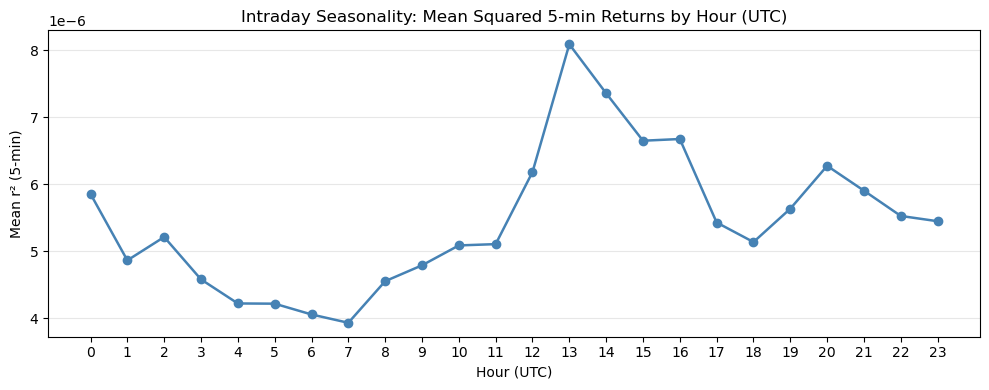

In [47]:
# 5.3  Plot hourly profile 
plt.figure(figsize=(10, 4))
hour_profile["mean_r2"].plot(marker="o", color="steelblue", linewidth=1.8)
plt.title("Intraday Seasonality: Mean Squared 5-min Returns by Hour (UTC)")
plt.xlabel("Hour (UTC)")
plt.ylabel("Mean r² (5-min)")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

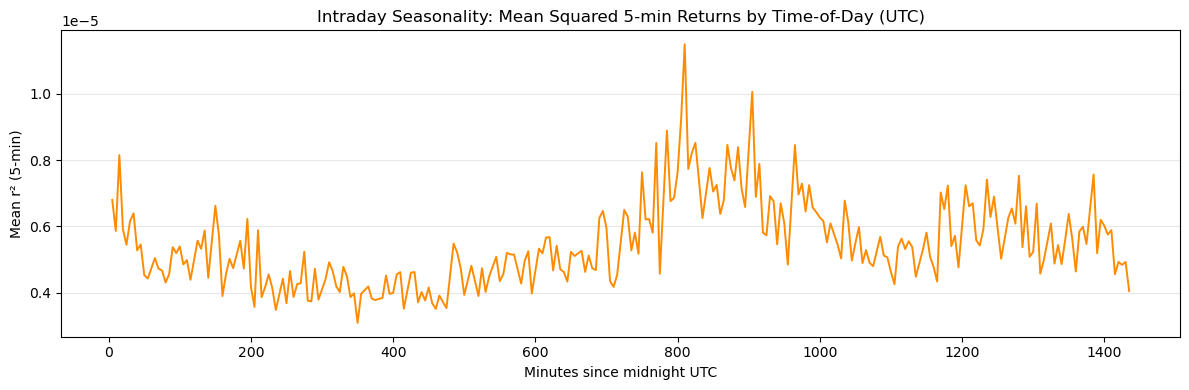

In [48]:
# 5.4  Plot 5-min bar profile (higher resolution) 
plt.figure(figsize=(12, 4))
bar_profile["mean_r2"].plot(color="darkorange", linewidth=1.4)
plt.title("Intraday Seasonality: Mean Squared 5-min Returns by Time-of-Day (UTC)")
plt.xlabel("Minutes since midnight UTC")
plt.ylabel("Mean r² (5-min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# 5.5  U-shape diagnostic 

# For Bitcoin (24/7), U-shape is typically weaker than equity markets.
# Testing: Are edge hours more volatile than mid-day hours?
edge_hours = list(range(0, 4)) + list(range(20, 24))   # 00–03 and 20–23 UTC
mid_hours  = list(range(10, 16))                        # 10–15 UTC

edge_mean = hour_profile.loc[edge_hours, "mean_r2"].mean()
mid_mean  = hour_profile.loc[mid_hours,  "mean_r2"].mean()

peak_hour = int(hour_profile["mean_r2"].idxmax())
min_hour  = int(hour_profile["mean_r2"].idxmin())

print("\n" + "="*55)
print("U-Shape Heuristic — Edge vs Mid Hours")
print("="*55)
print(f"Edge hours (00–03, 20–23 UTC) mean r² : {edge_mean:.6e}")
print(f"Mid  hours (10–15 UTC)        mean r² : {mid_mean:.6e}")
print(f"Edge / Mid ratio              : {edge_mean/mid_mean:.4f}")
print(f"Peak volatility hour (UTC)    : {peak_hour:02d}:00")
print(f"Minimum volatility hour (UTC) : {min_hour:02d}:00")

print("\nInterpretation:")
if edge_mean / mid_mean > 1.05:
    print("  Edge/Mid > 1.05 => Mild U-shape detected.")
    print("  Elevated volatility near session open/close hours.")
elif edge_mean / mid_mean < 0.97:
    print("  Edge/Mid < 0.97 => Inverse U-shape (mid-day peak).")
    print("  Peak volatility aligns with US/EU session overlap (13–16 UTC).")
    print("  This is consistent with Bitcoin literature: unlike equities,")
    print("  BTC shows highest activity during North American trading hours,")
    print("  not a classic open/close spike pattern.")
else:
    print("  No strong U-shape. Bitcoin trades 24/7 across global time zones;")
    print("  intraday seasonality is weaker than in traditional equity markets.")


U-Shape Heuristic — Edge vs Mid Hours
Edge hours (00–03, 20–23 UTC) mean r² : 5.460281e-06
Mid  hours (10–15 UTC)        mean r² : 6.413701e-06
Edge / Mid ratio              : 0.8513
Peak volatility hour (UTC)    : 13:00
Minimum volatility hour (UTC) : 07:00

Interpretation:
  Edge/Mid < 0.97 => Inverse U-shape (mid-day peak).
  Peak volatility aligns with US/EU session overlap (13–16 UTC).
  This is consistent with Bitcoin literature: unlike equities,
  BTC shows highest activity during North American trading hours,
  not a classic open/close spike pattern.


In [50]:
# 5.6  Day-of-week seasonality  
intraday["weekday"] = intraday.index.day_of_week   # 0=Mon, 6=Sun
dow_profile = (
    intraday.groupby("weekday")["r2_5m"]
    .mean()
    .to_frame("mean_r2")
)
dow_profile.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

print("\n" + "="*55)
print("Day-of-Week Seasonality — Mean r² by Weekday")
print("="*55)
print(dow_profile.to_string())


Day-of-Week Seasonality — Mean r² by Weekday
      mean_r2
Mon  0.000005
Tue  0.000006
Wed  0.000006
Thu  0.000006
Fri  0.000007
Sat  0.000004
Sun  0.000004


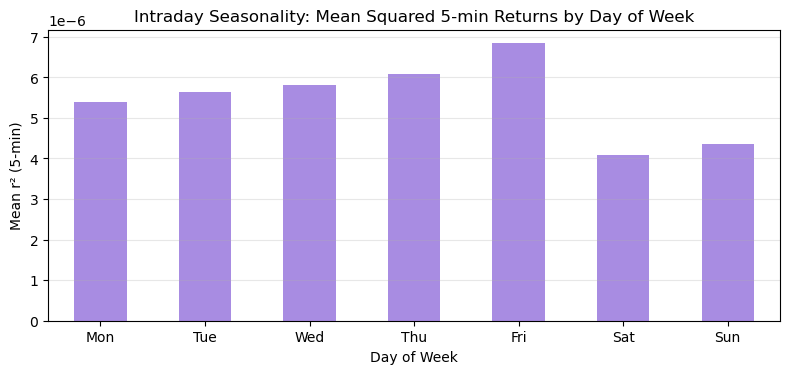

In [51]:
plt.figure(figsize=(8, 4))
dow_profile["mean_r2"].plot(kind="bar", color="mediumpurple", alpha=0.8, rot=0)
plt.title("Intraday Seasonality: Mean Squared 5-min Returns by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean r² (5-min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. COMBINED SUMMARY

In [52]:
print("\n" + "="*55)
print("THESIS SUMMARY — Key Stylised Facts")
print("="*55)
print(f"  Sample period  : {rv_hourly.index.min().date()} to {rv_hourly.index.max().date()}")
print(f"  Frequency      : 5-minute (12 bars / 11 valid returns per hour)")
print(f"  Total hours    : {rv_hourly['sufficient_data'].sum()}")
print(f"  Mean RV        : {rv_series.mean():.6f}")
print(f"  Mean log RV    : {logrv.mean():.4f}")
print(f"  log RV skew    : {skew(logrv):.4f}  (more symmetric than raw RV)")
print(f"  log RV kurt    : {kurtosis(logrv):.4f}")
print(f"  ACF(log RV,1)  : {logrv.autocorr(1):.4f}   (1-hour persistence)")
print(f"  ACF(log RV,24) : {logrv.autocorr(24):.4f}  (daily persistence)")
print(f"  ACF(log RV,168): {logrv.autocorr(168):.4f} (weekly persistence)")
print(f"  ADF p-value    : {adf_res[1]:.4g}  (reject unit root)")
print(f"  ARCH LM p-val  : {arch[1]:.4g}  (ARCH effects present)")
print("="*55)


THESIS SUMMARY — Key Stylised Facts
  Sample period  : 2016-01-01 to 2025-12-31
  Frequency      : 5-minute (12 bars / 11 valid returns per hour)
  Total hours    : 87672
  Mean RV        : 0.000060
  Mean log RV    : -10.8797
  log RV skew    : -0.1098  (more symmetric than raw RV)
  log RV kurt    : 1.5391
  ACF(log RV,1)  : 0.7254   (1-hour persistence)
  ACF(log RV,24) : 0.5511  (daily persistence)
  ACF(log RV,168): 0.4686 (weekly persistence)
  ADF p-value    : 6.549e-26  (reject unit root)
  ARCH LM p-val  : 0  (ARCH effects present)
